# Notebook 08: Federated Learning Simulation (FedAvg Algorithm)

## Objective
Simulate multi-hospital **Federated Learning using FedAvg (Federated Averaging)** across Hospital A, B, and C.

### Mathematical Formulation
In FedAvg, for round $t$, each hospital client $k$ updates local weights $w_k^t$ using local SGD. The central server aggregates parameters:
$$W_{global}^{t+1} = \sum_{k=1}^K 
rac{n_k}{N} w_k^t$$
where $n_k$ is the number of samples at client $k$ and $N = \sum n_k$.



In [4]:
import os
import sys
# Ensure project root is in sys.path for backend and scripts imports
root_path = os.path.abspath('..') if os.path.basename(os.getcwd()) == 'notebooks' else os.path.abspath('.')
if root_path not in sys.path:
    sys.path.insert(0, root_path)
import copy
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
import matplotlib.pyplot as plt

from backend.ml.model import DiabetesRiskModel

# Load node datasets
ha = pd.read_csv(os.path.join(root_path, "data", "hospitals", "hospital_A.csv"))
hb = pd.read_csv(os.path.join(root_path, "data", "hospitals", "hospital_B.csv"))
hc = pd.read_csv(os.path.join(root_path, "data", "hospitals", "hospital_C.csv"))

feature_cols = ['age', 'systolic_bp', 'diastolic_bp', 'heart_rate', 'bmi', 'glucose', 'hba1c', 'cholesterol', 'creatinine']
target_col = 'diabetes'

scaler = StandardScaler()
all_df = pd.concat([ha, hb, hc])
scaler.fit(all_df[feature_cols])

def get_dataloader(df, batch_size=32):
    X = scaler.transform(df[feature_cols].values)
    y = df[target_col].values
    ds = TensorDataset(torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.float32))
    return DataLoader(ds, batch_size=batch_size, shuffle=True), X, y

loader_a, X_a, y_a = get_dataloader(ha)
loader_b, X_b, y_b = get_dataloader(hb)
loader_c, X_c, y_c = get_dataloader(hc)

# Global Evaluation Dataset (Pooled Test Set)
X_global = scaler.transform(all_df[feature_cols].values)
y_global = all_df[target_col].values

print("Data Loaders initialized for 3 Hospital Nodes.")


Data Loaders initialized for 3 Hospital Nodes.


C:\Users\bahad\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\bahad\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\bahad\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\bahad\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


## 1. Define FedAvg Weight Aggregator Engine


In [5]:
def fedavg_aggregate(global_model, client_models, client_weights):
    global_dict = global_model.state_dict()
    for key in global_dict.keys():
        global_dict[key] = sum(client_weights[i] * client_models[i].state_dict()[key] for i in range(len(client_models)))
    global_model.load_state_dict(global_dict)
    return global_model

def train_local(client_model, dataloader, local_epochs=3, lr=0.01):
    client_model.train()
    optimizer = optim.Adam(client_model.parameters(), lr=lr)
    criterion = nn.BCEWithLogitsLoss()
    for _ in range(local_epochs):
        for bx, by in dataloader:
            optimizer.zero_grad()
            loss = criterion(client_model(bx).squeeze(), by)
            loss.backward()
            optimizer.step()
    return client_model


## 2. Execute Multi-Round Federated Learning Loop


In [6]:
global_model = DiabetesRiskModel(input_dim=len(feature_cols))
n_rounds = 10
client_loaders = [loader_a, loader_b, loader_c]
client_sizes = [len(ha), len(hb), len(hc)]
total_samples = sum(client_sizes)
weights = [sz / total_samples for sz in client_sizes]

round_accuracies = []
round_f1s = []

print("Starting Federated Learning Training Rounds...")

for r in range(1, n_rounds + 1):
    client_models = []
    for i, loader in enumerate(client_loaders):
        local_m = copy.deepcopy(global_model)
        local_m = train_local(local_m, loader, local_epochs=3, lr=0.01)
        client_models.append(local_m)
        
    global_model = fedavg_aggregate(global_model, client_models, weights)
    
    # Evaluate aggregated global model on global test set
    global_model.eval()
    with torch.no_grad():
        logits = global_model(torch.tensor(X_global, dtype=torch.float32)).squeeze()
        probs = torch.sigmoid(logits).numpy()
        preds = (probs >= 0.5).astype(float)
        
    acc = accuracy_score(y_global, preds)
    f1 = f1_score(y_global, preds, zero_division=0)
    
    round_accuracies.append(acc)
    round_f1s.append(f1)
    
    print(f"FL Round {r:02d}/{n_rounds:02d} -> Global Test Acc: {acc:.4f}, F1: {f1:.4f}")

print("Federated Learning Simulation Complete.")


Starting Federated Learning Training Rounds...
FL Round 01/10 -> Global Test Acc: 0.9220, F1: 0.9359
FL Round 02/10 -> Global Test Acc: 0.9453, F1: 0.9546
FL Round 03/10 -> Global Test Acc: 0.9480, F1: 0.9568
FL Round 04/10 -> Global Test Acc: 0.9500, F1: 0.9578
FL Round 05/10 -> Global Test Acc: 0.9507, F1: 0.9588
FL Round 06/10 -> Global Test Acc: 0.9507, F1: 0.9584
FL Round 07/10 -> Global Test Acc: 0.9507, F1: 0.9590
FL Round 08/10 -> Global Test Acc: 0.9547, F1: 0.9621
FL Round 09/10 -> Global Test Acc: 0.9520, F1: 0.9601
FL Round 10/10 -> Global Test Acc: 0.9533, F1: 0.9609
Federated Learning Simulation Complete.


## 3. Visualize FL Convergence Trajectory


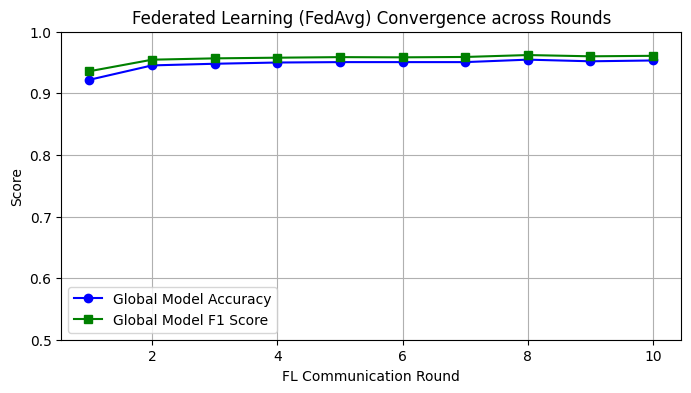

In [7]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, n_rounds + 1), round_accuracies, marker='o', label='Global Model Accuracy', color='blue')
plt.plot(range(1, n_rounds + 1), round_f1s, marker='s', label='Global Model F1 Score', color='green')
plt.title("Federated Learning (FedAvg) Convergence across Rounds")
plt.xlabel("FL Communication Round")
plt.ylabel("Score")
plt.ylim(0.5, 1.0)
plt.legend()
plt.grid(True)
plt.show()
